In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy import signal
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
import scipy.io as sio
from xgboost import XGBClassifier
import torch.nn.functional as F
import torch
from sklearn.base import BaseEstimator, ClassifierMixin
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression

2025-10-20 09:19:26.133483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760951966.504479      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760951966.606265      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
from __future__ import annotations
import os.path
import scipy.io

In [3]:
NUM_SUBJECTS = 7
NUM_DAYS = 8
NUM_POSTURES = 4

FILENAME_TEMPLATE = 'user_%d_day_%d_posture_%d.mat'
LOCAL_DATASET_FOLDER = '/kaggle/input/unibo-semg'

In [4]:
def load_file_data(idx_subject: int, idx_day: int, idx_posture: int,) -> tuple[
    np.ndarray[np.float32],  # emg
    np.ndarray[np.float32],  # label
    np.ndarray[np.float32],  # relabel
    np.ndarray[np.float32],  # gesture_counter
]:

    assert idx_subject < NUM_SUBJECTS
    assert idx_day < NUM_DAYS
    assert idx_posture <= NUM_POSTURES

    filename = FILENAME_TEMPLATE % (idx_subject + 1, idx_day + 1, idx_posture + 1)
    filepath = os.path.join(LOCAL_DATASET_FOLDER, filename)

    file_data = scipy.io.loadmat(filepath)

    # when needed, squeeze from (num_samples, 1) to (num_samples,)
    emg = file_data['emg']
    label = file_data['label'].squeeze()
    relabel = file_data['relabel'].squeeze()
    gesture_counter = file_data['gestureCounter'].squeeze()

    return emg, label, relabel, gesture_counter

In [5]:
idx_subject = 0
idx_day = 0
idx_posture = 0

emg, label, relabel, gesture_counter = load_file_data(idx_subject, idx_day, idx_posture)

EMG shape: (158536, 4)


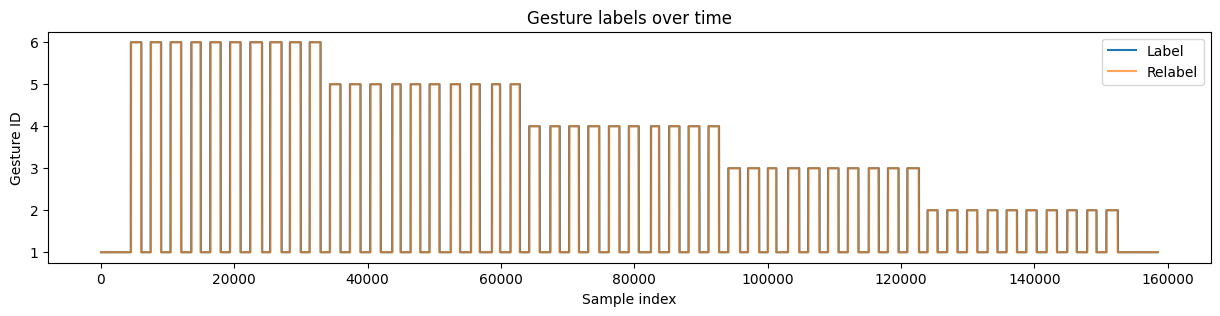

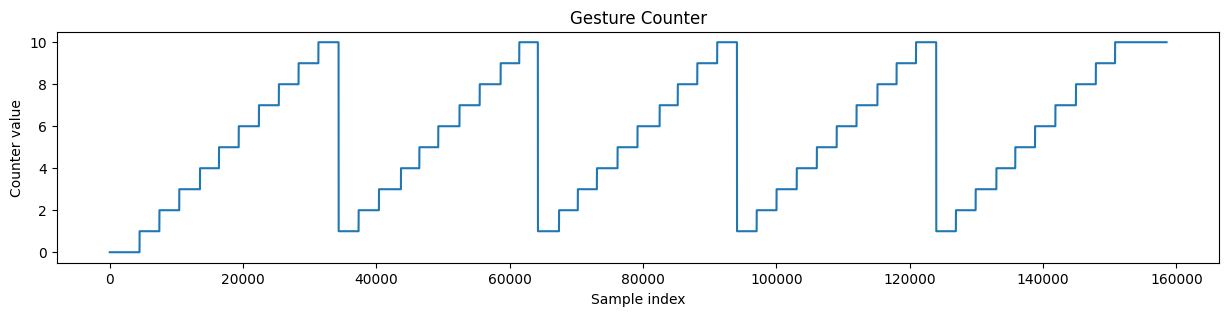

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Giả sử emg có dạng (num_samples, num_channels)
num_samples, num_channels = emg.shape
print(f"EMG shape: {emg.shape}")  # kiểm tra kích thước

# Vẽ label và relabel theo thời gian
plt.figure(figsize=(15, 3))
plt.plot(label, label="Label")
plt.plot(relabel, label="Relabel", alpha=0.7)
plt.title("Gesture labels over time")
plt.xlabel("Sample index")
plt.ylabel("Gesture ID")
plt.legend()
plt.show()

# Vẽ gesture_counter
plt.figure(figsize=(15, 3))
plt.plot(gesture_counter)
plt.title("Gesture Counter")
plt.xlabel("Sample index")
plt.ylabel("Counter value")
plt.show()

In [7]:
import scipy.io
mat = scipy.io.loadmat('/kaggle/input/unibo-semg/user_1_day_1_posture_1.mat')
emg = mat['emg']
print(emg.shape)  # (158536, 4)

(158536, 4)


In [8]:
import scipy.io
mat = scipy.io.loadmat('/kaggle/input/unibo-semg/user_1_day_1_posture_1.mat')
labels = mat['label']  
unique_labels = set(labels.flatten())
print(unique_labels)  # {1.0, 2.0, 3.0, 4.0, 5.0, 6.0}
print(len(unique_labels))  # 6

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0}
6


In [9]:
import scipy.io
mat = scipy.io.loadmat('/kaggle/input/unibo-semg/user_1_day_1_posture_1.mat')
labels = mat['label']
print(labels.shape)  # (158536, 1)
print(labels[4460:4470])  
'''
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [6.]
 [6.]
 [6.]
 [6.]]
'''

(158536, 1)
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [6.]
 [6.]
 [6.]
 [6.]]


'\n[[1.]\n [1.]\n [1.]\n [1.]\n [1.]\n [1.]\n [6.]\n [6.]\n [6.]\n [6.]]\n'

In [10]:
mat = scipy.io.loadmat('/kaggle/input/unibo-semg/user_1_day_1_posture_1.mat')

emg = mat['emg']  # Ma trận [158536, 4]
labels = mat['label']  # Vector [158536, 1]

mask_label_2 = (labels == 2.0).flatten()  # Tạo mask cho nhãn 2.0
emg_label_2 = emg[mask_label_2, :]  # Lấy các mẫu có nhãn 2.0
print("Shape của tín hiệu nhãn 2.0:", emg_label_2.shape) # Shape của tín hiệu nhãn 2.0: (15478, 4)

mask_label_4 = (labels == 4.0).flatten()  # Tạo mask cho nhãn 4.0
emg_label_4 = emg[mask_label_4, :]  # Lấy các mẫu có nhãn 4.0
print("Shape của tín hiệu nhãn 4.0:", emg_label_4.shape) # Shape của tín hiệu nhãn 4.0: (15408, 4)

Shape của tín hiệu nhãn 2.0: (15478, 4)
Shape của tín hiệu nhãn 4.0: (15408, 4)


In [11]:
sample_rate = 500
window_size_ms = 150
stride_ms = 37.5
window_size = int(window_size_ms / 1000 * sample_rate)
stride = int(stride_ms / 1000 * sample_rate)
trial_duration = 3
samples_per_trial = trial_duration * sample_rate
num_channels = 4
num_gestures = 6
num_postures = 4

notch_freq = 50.0  
q = 30.0

In [ ]:
def load_data(participant, day, posture, base_path='/kaggle/input/unibo-semg'):
    file = f'user_{participant}_day_{day}_posture_{posture}.mat'
    path = os.path.join(base_path, file)
    mat = sio.loadmat(path)
    emg = mat['emg']  # (samples, 4)
    labels = mat['label'].flatten()  # (samples,)
    return emg, labels

def load_and_prepare_day(participant, day, base_path):
    data = {}
    for posture in [1, 2, 3, 4]:
        emg, labels = load_data(participant, day, posture, base_path)
        data[posture] = (emg, labels)
    return data

def apply_bandpass(data, fs=sample_rate, low=20, high=225):  # Adjusted high to < Nyquist (250 Hz)
    sos = signal.butter(4, [low, high], btype='band', fs=fs, output='sos')
    filtered = signal.sosfiltfilt(sos, data, axis=1)
    return filtered 
    
def apply_notch_filter(data, fs=sample_rate, freq=notch_freq, q=q):
    b, a = signal.iirnotch(freq, q, fs)
    filtered = signal.filtfilt(b, a, data, axis=1)
    return filtered

def offset_correction(data):
    return data - np.mean(data, axis=1, keepdims=True)

def process_full_emg(emg):
    emg = emg.T  # channels x samples
    bandpassed = apply_bandpass(emg)
    filtered = apply_notch_filter(bandpassed)
    corrected = offset_correction(filtered)
    return corrected.T # samples x channels

def compute_pca_online(data, k=num_channels, beta=100, init_W=None):
    n, c = data.shape
    if init_W is None:
        W = np.random.randn(c, k)
        for j in range(k):
            norm = np.linalg.norm(W[:,j])
            if norm > 0:
                W[:,j] /= norm
    else:
        W = init_W.copy()
    t = 0
    for i in range(n):
        eta = 1.0 / (1 + beta * t)
        t += 1
        x = data[i,:].copy()
        x_temp = x.copy()
        for j in range(k):
            y = np.dot(W[:,j], x_temp)
            delta = eta * (y * x_temp - y**2 * W[:,j])
            W[:,j] += delta
            norm = np.linalg.norm(W[:,j])
            if norm > 0:
                W[:,j] /= norm
            y = np.dot(W[:,j], x_temp)
            x_temp -= y * W[:,j]
    return W
    
def align_W(W_ref, W_new):
    cost = -np.dot(W_ref.T, W_new)
    row_ind, col_ind = linear_sum_assignment(cost)
    W_aligned = W_new[:, col_ind]
    diag = np.diag(np.dot(W_ref.T, W_aligned))
    signs = np.sign(diag)
    W_aligned = W_aligned * signs[None,:]
    return W_aligned

def extract_windows(data):
    num_samples = data.shape[1]
    windows = []
    for start in range(0, num_samples - window_size + 1, stride):
        window = data[:, start:start + window_size]
        windows.append(window)
    return np.array(windows)

def extract_hudgins_9_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")
        
    mav = np.mean(np.abs(window), axis=1)
    zc = np.sum(np.diff(np.sign(window), axis=1) != 0, axis=1)
    ssc = np.sum(np.diff(np.sign(np.diff(window, axis=1)), axis=1) != 0, axis=1)
    wl = np.sum(np.abs(np.diff(window, axis=1)), axis=1)

    rms = np.sqrt(np.mean(window**2, axis=1))
    var = np.var(window, axis=1)
    std = np.std(window, axis=1)
    kurt = np.mean(((window - np.mean(window, axis=1, keepdims=True)) / std[:, None])**4, axis=1)
    skew = np.mean(((window - np.mean(window, axis=1, keepdims=True)) / std[:, None])**3, axis=1)

    features = np.concatenate([mav, zc, ssc, wl, rms, var, std, kurt, skew])
    return features

def extract_hudgins_5_features(window):
    if window.ndim != 2:
        raise ValueError("Window must be a 2D array (channels × samples)")
        
    mav = np.mean(np.abs(window), axis=1)
    zc = np.sum(np.diff(np.sign(window), axis=1) != 0, axis=1)
    ssc = np.sum(np.diff(np.sign(np.diff(window, axis=1)), axis=1) != 0, axis=1)
    wl = np.sum(np.abs(np.diff(window, axis=1)), axis=1)

    features = np.concatenate([mav, zc, ssc, wl])
    return features

def extract_sntdf_features(window):
    
    mav_nl = np.log(np.mean(np.abs(window), axis=1) + 1e-8)
    power0 = np.mean(window**0, axis=1)
    power2 = np.mean(window**2, axis=1)
    power4 = np.mean(window**4, axis=1)
    power6 = np.mean(window**6, axis=1)

    diff1 = np.mean(np.abs(np.diff(window, axis=1)), axis=1)
    diff2 = np.mean(np.abs(np.diff(np.diff(window, axis=1), axis=1)), axis=1)

    corr = np.corrcoef(window)
    corr_flat = corr[np.triu_indices(num_channels, k=1)]  # Upper triangle
    features = np.concatenate([mav_nl, power0, power2, power4, power6, diff1, diff2, corr_flat])
    return features

def extract_combine_features(window):
    features_sntdf = extract_sntdf_features(window)
    features_hudgins = extract_hudgins_9_features(window)
    
    combined_features = np.concatenate([features_sntdf, features_hudgins])    
    return combined_features

def process_segment(emg_seg, features='hudgin_5'):
    windows = extract_windows(emg_seg)
    if features == 'hudgin_5':
        features = np.array([extract_hudgins_5_features(w) for w in windows])
    elif features == 'hudgin_9':
        features = np.array([extract_hudgins_9_features(w) for w in windows])
    elif features == 'sntdf':
        features = np.array([extract_sntdf_features(w) for w in windows])
    elif features == 'combine':
        features = np.array([extract_combine_features(w) for w in windows])
    return features

def prepare_dataset(emg, labels, posture=None, features='hudgin_5'):
    emg = emg.T
    features_list = []
    gesture_labels = []
    posture_labels = []

    diff = np.diff(labels)
    starts = np.where(diff != 0)[0] + 1
    starts = np.insert(starts, 0, 0)
    ends = np.append(starts[1:], len(labels))

    for start, end in zip(starts, ends):
        seg_label = labels[start]
        seg_emg = emg[:, start:end]
        if end - start < window_size:
            print('skip segments too small for windowing')
            continue
        feat = process_segment(seg_emg, features=features)
        num_windows = feat.shape[0]
        features_list.append(feat)
        gesture_labels.extend([seg_label] * num_windows)
        if posture is not None:
            posture_labels.extend([posture] * num_windows)

    X = np.vstack(features_list) if features_list else np.empty((0, num_channels * 4))
    y_gesture = np.array(gesture_labels)
    y_posture = np.array(posture_labels) if posture is not None else None

    return X, y_gesture, y_posture

def split_data(X, y_gesture, y_posture=None, test_size=0.2):
    indices = np.arange(X.shape[0])
    if y_posture is None:
        y_posture = np.zeros_like(y_gesture)
    X_train, X_test, yg_train, yg_test, yp_train, yp_test, idx_train, idx_test = train_test_split(X, y_gesture, y_posture, indices, test_size=test_size, random_state=200, stratify=y_gesture)
    
    return X_train, X_test, yg_train, yg_test, yp_train, yp_test

def evaluate_lda(X, y, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)
    accs = []
    for train_idx, val_idx in kf.split(X, y):
        clf = LinearDiscriminantAnalysis()
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[val_idx])
        accs.append(accuracy_score(y[val_idx], pred))
    return np.mean(accs)

def evaluate_svm(X, y, n_splits=5):
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=200)
    accs = []
    for train_idx, val_idx in kf.split(X, y):
        clf = SVC(kernel='rbf', C=1.0, gamma='scale')
        clf.fit(X[train_idx], y[train_idx])
        pred = clf.predict(X[val_idx])
        accs.append(accuracy_score(y[val_idx], pred))
    return np.mean(accs)

def standard_classification(data, features='hudgin_5'):
    results = {}
    for pos in data:
        emg, labels = data[pos]
        X_pos, y_pos_gesture, _ = prepare_dataset(emg, labels, pos, features=features)
        if len(X_pos) == 0:
            print(f"Warning: No data for posture {pos}")
            continue
        X_train, X_test, y_train, y_test, _, _ = split_data(X_pos, y_pos_gesture)
        cv_acc = evaluate_lda(X_train, y_train)
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        results[pos] = {"cv_acc": cv_acc, "test_acc": test_acc}
    return results

def naive_transfer(data, config_postures, features='hudgin_5'):
    results = np.zeros((len(config_postures), len(config_postures)))
    for i, src in enumerate(config_postures):
        emg_src, labels_src = data[src]
        X_src, y_src, _ = prepare_dataset(emg_src, labels_src, src, features=features)
        if len(X_src) == 0:
            print(f"Warning: No data for source posture {src}")
            continue
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_src, y_src)
        processed_src = process_full_emg(emg_src)
        W_ref = compute_pca_online(processed_src)
        for j, tgt in enumerate(config_postures):
            if src == tgt:
                acc = evaluate_lda(X_src, y_src)
            else:
                emg_tgt, labels_tgt = data[tgt]
                processed_tgt = process_full_emg(emg_tgt)
                W_new = compute_pca_online(processed_tgt, init_W=W_ref)
                W_new = align_W(W_ref, W_new)
                transformed_emg = processed_tgt @ W_new @ W_ref.T
                X_tgt, y_tgt, _ = prepare_dataset(transformed_emg, labels_tgt, tgt, features=features)
                if len(X_tgt) == 0:
                    print(f"Warning: No data for target posture {tgt}")
                    continue
                pred = clf.predict(X_tgt)
                acc = accuracy_score(y_tgt, pred)
            results[i, j] = acc
    return results

def posture_classification(data, config_postures, features='hudgin_5'):
    
    results = {}
    for gesture in range(1, num_gestures+1):
        X_g = []
        y_g_posture = []
        for pos in config_postures:
            emg, labels = data[pos]
            X_pos, y_gesture, _ = prepare_dataset(emg, labels, pos, features=features)
            mask = (y_gesture == gesture)
            X_g.append(X_pos[mask])
            y_g_posture.append(np.full(len(X_pos[mask]), pos))
        X_g = np.vstack(X_g) if X_g else np.empty((0, num_channels * 4))
        y_g_posture = np.concatenate(y_g_posture) if y_g_posture else np.array([])
        if len(X_g) == 0:
            print(f"Warning: No data for gesture {gesture}")
            continue
        X_train, X_test, y_train, y_test, _, _ = split_data(X_g, y_g_posture)
        cv_acc = evaluate_lda(X_train, y_train)
        clf = LinearDiscriminantAnalysis()
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        test_acc = accuracy_score(y_test, y_pred)
        results[gesture] = {"cv_acc": cv_acc, "test_acc": test_acc}
    return results

class MLP48(BaseEstimator, ClassifierMixin):
    def __init__(self, input_dim=None, n_classes=None, lr=1e-3, epochs=30, batch_size=32, verbose=0):
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None
        self.loss_history = []

    def _build_model(self):
        model = Sequential()
        model.add(Dense(48, activation='relu', input_dim=self.input_dim))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(24, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
        model.add(Dense(self.n_classes, activation='softmax'))

        model.compile(optimizer=Adam(learning_rate=self.lr),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
        return model

    def fit(self, X, y):
        if self.input_dim is None:
            self.input_dim = X.shape[1]
        if self.n_classes is None:
            self.n_classes = len(np.unique(y))
        y_cat = to_categorical(y, num_classes=self.n_classes)
        self.model = self._build_model()

        history = self.model.fit(
            X, y_cat,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose)
        self.loss_history = history.history['loss']  # 👈 Lưu loss
        return self

    def predict(self, X):
        preds = np.argmax(self.model.predict(X, verbose=0), axis=1)
        return preds

def meta_learner_ensemble(X_train, y_train, X_test, random_state=42, cv=4):
    # === Base models ===

    le = LabelEncoder()
    y_train_enc = le.fit_transform(y_train)

    svc = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=random_state)
    xgb = XGBClassifier(
        use_label_encoder=False, eval_metric='mlogloss', n_estimators=100,
        max_depth=4, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, random_state=random_state, verbosity=0
    )
    mlp48 = MLP48(
        input_dim=X_train.shape[1], n_classes=len(np.unique(y_train_enc)),
        epochs=30, verbose=0
    )

    base_models = [svc, xgb, mlp48]

    cv_split = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    oof_probas = np.zeros((X_train.shape[0], len(np.unique(y_train_enc)) * len(base_models)))
    test_probas = np.zeros((X_test.shape[0], len(np.unique(y_train_enc)) * len(base_models)))

    for i, model in enumerate(base_models):
        oof_fold_preds = np.zeros((X_train.shape[0], len(np.unique(y_train_enc))))
        test_fold_preds = np.zeros((cv, X_test.shape[0], len(np.unique(y_train_enc))))

        for j, (train_idx, val_idx) in enumerate(cv_split.split(X_train, y_train_enc)):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train_enc[train_idx], y_train_enc[val_idx]

            if isinstance(model, MLP48):
                model_fold = MLP48(input_dim=X_train.shape[1],
                                   n_classes=len(np.unique(y_train_enc)),
                                   epochs=30, verbose=0)
                model_fold.fit(X_tr, y_tr)
                val_pred = model_fold.model.predict(X_val, verbose=0)
                test_pred = model_fold.model.predict(X_test, verbose=0)
            else:
                model_fold = model.__class__(**model.get_params())
                model_fold.fit(X_tr, y_tr)
                val_pred = model_fold.predict_proba(X_val)
                test_pred = model_fold.predict_proba(X_test)

            oof_fold_preds[val_idx] = val_pred
            test_fold_preds[j, :, :] = test_pred

        oof_probas[:, i * len(np.unique(y_train_enc)):(i + 1) * len(np.unique(y_train_enc))] = oof_fold_preds
        test_probas[:, i * len(np.unique(y_train_enc)):(i + 1) * len(np.unique(y_train_enc))] = test_fold_preds.mean(axis=0)

    scaler = MinMaxScaler()
    X_meta_train = scaler.fit_transform(oof_probas)
    X_meta_test  = scaler.transform(test_probas)

    meta_model = LogisticRegression(max_iter=500, random_state=random_state)
    meta_model.fit(X_meta_train, y_train_enc)

    #y_pred_train = meta_model.predict(X_meta_train)
    #y_pred_test  = meta_model.predict(X_meta_test)

    y_pred_train = le.inverse_transform(meta_model.predict(X_meta_train))
    y_pred_test  = le.inverse_transform(meta_model.predict(X_meta_test))

    return y_pred_train, y_pred_test

def hmc_classification(data, test_size=0.2, n_splits=5, random_state=200, features='hudgin_5'):
    X_list = []
    yg_list = []
    yp_list = []
    for pos in data:
        emg, labels = data[pos]
        X, y_gesture, y_posture = prepare_dataset(emg, labels, pos, features=features)
        X_list.append(X)
        yg_list.append(y_gesture)
        yp_list.append(y_posture)
    X_merged = np.vstack(X_list)
    yg_merged = np.concatenate(yg_list)
    yp_merged = np.concatenate(yp_list)

    X_train, X_test, yg_train, yg_test, yp_train, yp_test = train_test_split(X_merged, yg_merged, yp_merged, test_size=test_size, random_state=random_state, stratify=yg_merged)
    
    #X_train_norm = X_train
    #X_test_norm = X_test

    scaler = StandardScaler()
    X_train_norm = scaler.fit_transform(X_train)
    X_test_norm = scaler.transform(X_test)

    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    pos_cv_scores = []
    multi_label_cv_scores = []
    soft_cv_scores = []

    for train_idx, val_idx in kf.split(X_train_norm, yp_train):
        X_cv_train, X_cv_val = X_train_norm[train_idx], X_train_norm[val_idx]
        yg_cv_train, yg_cv_val = yg_train[train_idx], yg_train[val_idx]
        yp_cv_train, yp_cv_val = yp_train[train_idx], yp_train[val_idx]

        #clf_pos = LinearDiscriminantAnalysis()
        #clf_pos = SVC(kernel='rbf', C=1.0, gamma='scale')
        #clf_pos.fit(X_cv_train, yp_cv_train)
        #pos_pred_cv = clf_pos.predict(X_cv_val)
        temp, pos_pred_cv = meta_learner_ensemble(X_cv_train, yp_cv_train, X_cv_val)
        pos_cv_acc = accuracy_score(yp_cv_val, pos_pred_cv)
        pos_cv_scores.append(pos_cv_acc)

        std = np.std(pos_pred_cv)
        pos_pred_norm_cv = (pos_pred_cv - np.mean(pos_pred_cv)) / (std + 1e-8)
        X_aug_cv = np.hstack((X_cv_val, pos_pred_norm_cv.reshape(-1, 1)))
        X_aug_train_cv = np.hstack((X_cv_train,
            ((temp - np.mean(temp)) / 
             np.std(temp + 1e-8)).reshape(-1, 1)))

        gesture_clfs = {}
        unique_pos = np.unique(yp_cv_train)
        
        for pos in unique_pos:
            mask = (yp_cv_train == pos)
            X_pos_aug = X_aug_train_cv[mask]
            y_pos_gesture = yg_cv_train[mask]
            if len(np.unique(y_pos_gesture)) > 1:
                clf_g = LinearDiscriminantAnalysis()
                clf_g.fit(X_pos_aug, y_pos_gesture)
                gesture_clfs[pos] = clf_g

        preds_gesture = []
        soft_preds = []
        for i in range(len(X_cv_val)):
            p_pred = pos_pred_cv[i]
            x_aug = X_aug_cv[i].reshape(1, -1)  # Fixed to row vector
            true_p = yp_cv_val[i]

            if p_pred in gesture_clfs:
                pred_g = gesture_clfs[p_pred].predict(x_aug)[0]
            else:
                pred_g = np.random.choice(np.unique(yg_cv_train))
                
            preds_gesture.append(pred_g)

            if true_p in gesture_clfs:
                pred_g_soft = gesture_clfs[true_p].predict(x_aug)[0]
            else:
                pred_g_soft = np.random.choice(np.unique(yg_cv_train))
            
            soft_preds.append(pred_g_soft)

        multi_label_acc = np.mean((pos_pred_cv == yp_cv_val) & (np.array(preds_gesture) == yg_cv_val))
        soft_acc = accuracy_score(yg_cv_val, soft_preds)
        multi_label_cv_scores.append(multi_label_acc)
        soft_cv_scores.append(soft_acc)

    cv_pos_acc = np.mean(pos_cv_scores)
    cv_multi_label_acc = np.mean(multi_label_cv_scores)
    cv_soft_acc = np.mean(soft_cv_scores)

    # Final training on full training set
    #clf_pos = LinearDiscriminantAnalysis()
    #clf_pos = SVC(kernel='rbf', C=1.0, gamma='scale')
    #clf_pos.fit(X_train_norm, yp_train)
    #pos_pred_test = clf_pos.predict(X_test_norm)
    temp_new, pos_pred_test = meta_learner_ensemble(X_train_norm, yp_train, X_test_norm)
    pos_acc = accuracy_score(yp_test, pos_pred_test)
    
    pos_pred_norm = (pos_pred_test - np.mean(pos_pred_test)) / (np.std(pos_pred_test) + 1e-8)
    X_aug_test = np.hstack((X_test_norm, pos_pred_norm.reshape(-1, 1)))
    X_aug_train = np.hstack((X_train_norm,
        ((temp_new - np.mean(temp_new)) / 
         np.std(temp_new + 1e-8)).reshape(-1, 1)))

    gesture_clfs = {}
    unique_pos = np.unique(yp_train)
    for pos in unique_pos:
        mask = (yp_train == pos)
        X_pos_aug = X_aug_train[mask]
        y_pos_gesture = yg_train[mask]
        if len(np.unique(y_pos_gesture)) > 1:
            clf_g = LinearDiscriminantAnalysis()
            clf_g.fit(X_pos_aug, y_pos_gesture)
            gesture_clfs[pos] = clf_g

    preds_gesture = []
    soft_preds = []
    for i in range(len(X_test_norm)):
        p_pred = pos_pred_test[i]
        x_aug = X_aug_test[i].reshape(1, -1)
        true_p = yp_test[i]
        
        # HMC prediction
        if p_pred in gesture_clfs:
            pred_g = gesture_clfs[p_pred].predict(x_aug)[0]
        else:
            pred_g = np.random.choice(np.unique(yg_train))

        preds_gesture.append(pred_g)
        
        # Soft HMC
        if true_p in gesture_clfs:
            pred_g_soft = gesture_clfs[true_p].predict(x_aug)[0]
        else:
            pred_g_soft = np.random.choice(np.unique(yg_train))

        soft_preds.append(pred_g_soft)

    multi_label_acc = np.mean((pos_pred_test == yp_test) & (np.array(preds_gesture) == yg_test))
    soft_acc = accuracy_score(yg_test, soft_preds)
    
    return cv_pos_acc, cv_multi_label_acc, cv_soft_acc, pos_acc, multi_label_acc, soft_acc
    
def run_pipeline(participant=1, day=1, posture=1, features='hudgin_5'):
    emg, labels = load_data(participant, day, posture)
    X, y_gesture, y_posture = prepare_dataset(emg, labels, posture, features=features)

    print("len(X): ", len(X))

    data = {posture: (emg, labels)}
    config = [posture]
    
    standard_results = standard_classification(data, features=features)
    transfer_results = naive_transfer(data, config, features=features)
    pos_class_results = posture_classification(data, config, features=features)

    return {'standard': standard_results, 'transfer': transfer_results, 'pos_class': pos_class_results}

def run_pipeline_hmc(participant=1, base_path='/kaggle/input/unibo-semg', features='hudgin_5'):
    
    data_day1 = load_and_prepare_day(participant, 1, base_path)
    data_day2 = load_and_prepare_day(participant, 2, base_path)
    data_merged = {**data_day1, **data_day2}  
    hmc_results = hmc_classification(data_merged, features=features)
    return {'hmc': hmc_results}

In [14]:
all_results_hmc = []

for participant in [2]:
    results_hmc = run_pipeline_hmc(participant=participant, features='combine')
    # results_hmc['hmc'] là tuple
    all_results_hmc.append(results_hmc['hmc'])

all_results_hmc = np.array(all_results_hmc)

cv_pos_accs        = all_results_hmc[:, 0]
cv_multi_label_accs = all_results_hmc[:, 1]
cv_soft_accs        = all_results_hmc[:, 2]
pos_accs           = all_results_hmc[:, 3]
multi_label_accs   = all_results_hmc[:, 4]
soft_accs          = all_results_hmc[:, 5]

print("run_pipeline_hmc mean CV Position Acc:", np.mean(cv_pos_accs))
print("run_pipeline_hmc mean CV Multi-label Acc:", np.mean(cv_multi_label_accs))
print("run_pipeline_hmc mean CV Soft Acc:", np.mean(cv_soft_accs))
print("run_pipeline_hmc mean Test Position Acc:", np.mean(pos_accs))
print("run_pipeline_hmc mean Test Multi-label Acc:", np.mean(multi_label_accs))
print("run_pipeline_hmc mean Test Soft Acc:", np.mean(soft_accs))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-10-20 09:31:14.178547: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When u

run_pipeline_hmc mean CV Position Acc: 0.6977126120718558
run_pipeline_hmc mean CV Multi-label Acc: 0.6759447765592723
run_pipeline_hmc mean CV Soft Acc: 0.9578614891902708
run_pipeline_hmc mean Test Position Acc: 0.6971613472569496
run_pipeline_hmc mean Test Multi-label Acc: 0.676717164288866
run_pipeline_hmc mean Test Soft Acc: 0.9594057949698485
